In [1]:
import numpy as np


def read_latency_data(file, ignore):
    data = {"end_to_end": [], "service": []}
    with open(file, "r") as file:
        for line in file.readlines():
            span, latency = line.strip().split(",")
            assert span in data.keys()
            data[span].append(int(latency))
    for span in data.keys():
        n_ignore = int(len(data[span]) * ignore)
        data[span] = data[span][n_ignore:]
    return data 


def get_pctl(data, pctl):
    data = np.sort(data)
    tail = np.percentile(data, pctl).astype(int)
    return tail

In [2]:
rps_values = list(range(100, 2001, 100))
e2e_data = {
    "rps": [],
    "fcfs": [],
    "masa": [],
}
svc_data = {
    "rps": [],
    "fcfs": [],
    "masa": [],
}

pctl = 99
for rps in rps_values:
    e2e_data["rps"].append(rps)
    svc_data["rps"].append(rps)

    file = f"r{rps}-fcfs.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["fcfs"].append(get_pctl(data["end_to_end"], pctl))
    svc_data["fcfs"].append(get_pctl(data["service"], pctl))

    file = f"r{rps}-masa.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["masa"].append(get_pctl(data["end_to_end"], pctl))
    svc_data["masa"].append(get_pctl(data["service"], pctl))

print(e2e_data)
print()
print(svc_data)

{'rps': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000], 'fcfs': [48315, 53681, 57729, 63020, 67162, 73725, 81071, 87380, 97402, 107448, 118527, 136178, 158182, 182065, 219842, 278677, 384104, 545364, 945977, 926938], 'masa': [48121, 53325, 56681, 61571, 64237, 68465, 75025, 79538, 87702, 93925, 100327, 114426, 133848, 151024, 179378, 219822, 301254, 520907, 731703, 724313]}

{'rps': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000], 'fcfs': [13398, 13519, 13748, 14316, 15027, 15819, 17228, 18649, 20307, 24383, 28347, 32346, 36681, 48242, 52547, 74922, 105906, 169880, 210850, 258314], 'masa': [13398, 13569, 13772, 14451, 15013, 16512, 18408, 20830, 23071, 27887, 32247, 37648, 43633, 56261, 66902, 82543, 101689, 190134, 280278, 304902]}


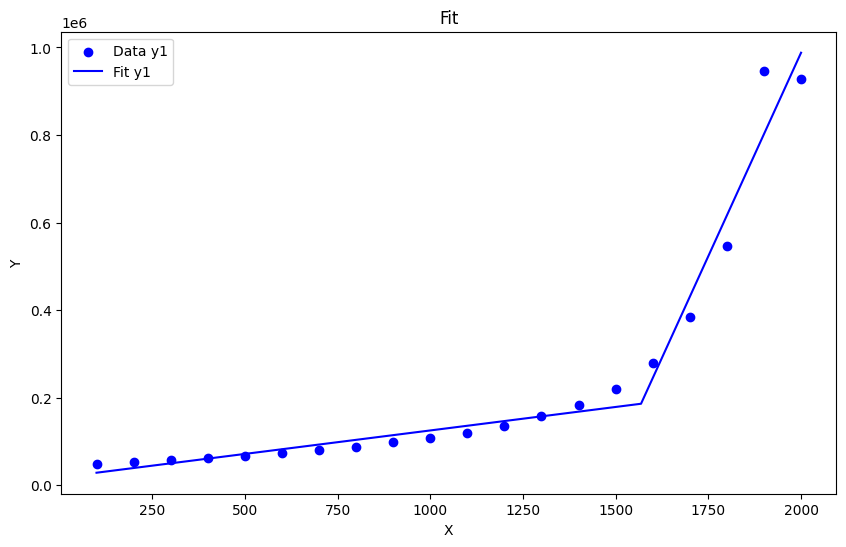

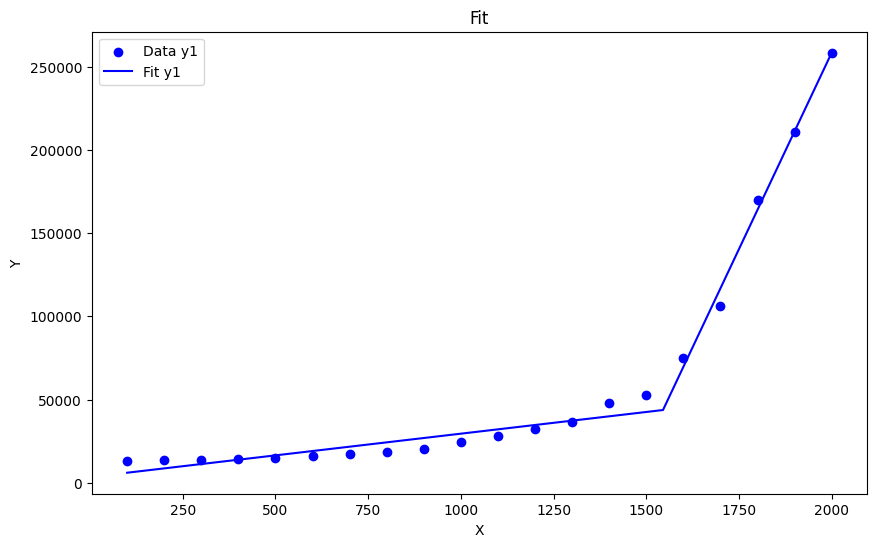

40000 209 4000 21 

45000 255 4500 40 

50000 302 5000 59 

55000 348 5500 78 

60000 395 6000 97 

65000 442 6500 116 

70000 488 7000 136 

75000 535 7500 155 

80000 581 8000 174 

85000 628 8500 193 

90000 675 9000 212 

95000 721 9500 232 

100000 768 10000 251 

105000 814 10500 270 

110000 861 11000 289 

115000 908 11500 308 

120000 954 12000 328 

125000 1001 12500 347 

130000 1048 13000 366 



In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pwlf
from scipy.optimize import fsolve


def plot(data):
    n_points = len(data["rps"])
    x = np.array(data["rps"][:n_points])
    y1 = np.array(data["fcfs"][:n_points])
    # y2 = np.array(data["masa"][:n_points])

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y1, color="blue", label="Data y1")
    # plt.scatter(x, y2, color="green", label="Data y2")

    fit = pwlf.PiecewiseLinFit(x, y1)
    fit.fit(2)
    x_hat = np.linspace(min(x), max(x), num=10000)
    y_hat = fit.predict(x_hat)
    plt.plot(x_hat, y_hat, color="blue", label="Fit y1")

    plt.title("Fit")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.show()

    return fit


def solve(p, target):
    return fsolve(lambda x: p(x) - target, 1000)


e2e_fit = plot(e2e_data)
svc_fit = plot(svc_data)

slos = [
    40000,
    45000,
    50000,
    55000,
    60000,
    65000,
    70000,
    75000,
    80000,
    85000,
    90000,
    95000,
    100000,
    105000,
    110000,
    115000,
    120000,
    125000,
    130000,
]
for slo in slos:
    print(
        round(slo),
        round(solve(e2e_fit.predict, slo)[0]),
        round(slo / 10),
        round(solve(svc_fit.predict, slo / 10)[0]),
        "\n",
    )